# Aula 25/03 e 01/04

### Implementação Algoritmo Genético Binário
-- Com 3 funções de teste --

Para trocar a função a ser testada comentar e descomentar a função fitness e as variáveis globais de cada uma, respectivamente.




## Função g11 => f(x) = x1² + (x2 − 1)² com a restrição => (x2 - x1²) = 0

intervalo: −1 ≤ x1 ≤ 1 e −1 ≤ x2 ≤ 1. \
A solução ótima é: x∗ = (−0.707036070037170616,0.500000004333606807) \
onde f(x∗) = 0.7499.


In [ ]:
# f(x) = x1² + (x2 − 1)²
def g11(x1, x2):
    return x1**2 + (x2 - 1)**2

# restrição: (x2 - x1²) = 0
def h1(x1, x2):
    return abs(x2 - x1**2)

# def fitness(x1, x2):
#   y = g11(x1, x2)
#   y_h1 = h1(x1, x2)

#   if y_h1 > 10e-6:
#       y += y_h1

#   return(x1, x2, y)

# MIN_PLOT = 0.70
# MAX_PLOT = 0.80
# TAM_POP = 50
# MIN_VAL_X1 = -1
# MAX_VAL_X1 = 1
# MIN_VAL_X2 = -1
# MAX_VAL_X2 = 1

## Função g06 => (x1 − 10)³ + (x2 − 20)³ \
restrição 1: -(x1 - 5)² - (x2 - 5)² + 100 <= 0 \
restrição 2: (x1 - 6)² + (x2 − 5)² - 82.81 <= 0

intervalo: 13 ≤ x1 ≤ 100 e 0 ≤ x2 ≤ 100. \
A solução ótima é = (14.09500000000000064,0.8429607892154795668, −6961.81387558015)

In [ ]:
#f(x) = (x1 − 10)³ + (x2 − 20)³
def g06(x1, x2):
    return (x1 - 10)**3 + (x2 - 20)**3

#restrição 1: -(x1 - 5)² - (x2 - 5)² + 100 <= 0
def g1(x1, x2):
    return -(x1 - 5)**2 - (x2 - 5)**2 + 100

#restrição 2: (x1 - 6)² + (x2 − 5)² - 82.81 <= 0
def g2(x1, x2):
    return (x1 - 6)**2 + (x2 - 5)**2 - 82.81

def fitness(x1, x2):
  y = g06(x1, x2)
  y_g1 = g1(x1, x2)
  y_g2 = g2(x1, x2)

  if y_g1 > 0:
      y += y_g1 * 10000
  if y_g2 > 0:
      y += y_g2 * 10000

  return(x1, x2, y)

MIN_PLOT = -7000
MAX_PLOT = 0
TAM_POP = 50
MIN_VAL_X1 = 13
MAX_VAL_X1 = 100
MIN_VAL_X2 = 0
MAX_VAL_X2 = 100

## Função Booth Function (sem restrição) =>  (x1 + 2x2 - 7)² + (2x1 + x2 - 5)²

intervalo: -10 <= x1, x2 <= 10
A solução ótima é = (1, 3, 0)

In [ ]:
def booth(x1, x2):
    return (x1 + 2*x2 - 7)**2 + (2*x1 + x2 - 5)**2

# def fitness(x1, x2):
#   y = booth(x1, x2)
#   return(x1, x2, y)

# MIN_PLOT = 0
# MAX_PLOT = 8
# TAM_POP = 50
# MIN_VAL_X1 = -10
# MAX_VAL_X1 = 10
# MIN_VAL_X2 = -10
# MAX_VAL_X2 = 10

## Gerar Populaçao Inicial

In [ ]:
import random
def gerar_populacao_inicial():
  populacao = []
  for x in range(TAM_POP):
    x1 = random.uniform(MIN_VAL_X1, MAX_VAL_X1)
    x2 = random.uniform(MIN_VAL_X2, MAX_VAL_X2)
    tupla_individuo = fitness(x1, x2)
    populacao.append(tupla_individuo)

  return populacao

print(gerar_populacao_inicial())

[(67.44849287037852, 69.79278195922537, 79225169.94342187), (19.47861183437145, 45.96667626794759, 17789675.517477725), (60.29889937105442, 14.554702174985778, 29695621.778730303), (46.05877919250414, 18.11756918318269, 16986542.353056926), (15.428334827980354, 55.53801530330854, 25646787.59534224), (49.68950583061578, 66.66602394250098, 56450760.883410156), (87.8333283029869, 83.66859486046106, 128755923.53307211), (70.82856346324442, 24.604775874656394, 45267969.04488214), (92.14643723428624, 98.4697807875979, 161787491.0816512), (81.47771660985113, 13.186595561481084, 57175828.44682594), (51.822729826247446, 40.5685022972458, 32902164.862353772), (43.415369372870664, 42.43938305670297, 27236682.66461186), (64.89530950195737, 48.52312630765423, 52989732.31400332), (67.08406324295746, 59.174461987692325, 66079383.349159345), (36.27416176002409, 36.86354657747333, 18512938.233108427), (57.627319307249685, 17.501859936781305, 27496686.396743182), (74.09586090408476, 98.12246034626995, 1

## Tranformar de Real para Binário e Binário para Real (cada número individualmente)

In [ ]:
# Real para Binário
def real_para_binario(x, MIN_VAL, MAX_VAL, bits=25):
    max_int = (2 ** bits) - 1 #maior número representável (ex: 12 bits => 4095)
    inteiro = int((x - MIN_VAL) / (MAX_VAL - MIN_VAL) * max_int)
    return format(inteiro, f'0{bits}b') #formata o numero em uma string de binario, com a quantidade de bits

# Binário para Real
def binario_para_real(bin_str, MIN_VAL, MAX_VAL):
    inteiro = int(bin_str, 2)
    max_int = (2 ** len(bin_str)) - 1
    x = MIN_VAL + (inteiro / max_int) * (MAX_VAL - MIN_VAL)
    return x

print("Real -0.285 em binário: ", real_para_binario(-0.258, -1, 1))
print("Binario para real: ", binario_para_real(real_para_binario(-0.258, -1, 1), -1, 1))


Real -0.285 em binário:  0101111011111001110110101
Binario para real:  -0.25800005370378654


## Converter População toda de Binário para Real e de Real para Binário

In [ ]:
def converter_populacao_para_binario(populacao, bits=25):
    populacao_bin = []

    for x1, x2, y in populacao:
        bin_x1 = real_para_binario(x1, MIN_VAL_X1, MAX_VAL_X1, bits)
        bin_x2 = real_para_binario(x2, MIN_VAL_X2, MAX_VAL_X2, bits)

        populacao_bin.append((bin_x1, bin_x2, y))

    return populacao_bin
print(converter_populacao_para_binario(gerar_populacao_inicial()))

[('0110111000001111001010011', '1000111010111000110101000', 44756176.50640366), ('0001100010000111101010010', '1010011000011111011110010', 37486110.96372527), ('0001101110010011010010110', '1011110100011011010000010', 49440695.02512373), ('0100111110111101111010101', '1000001111110110000110000', 32525105.74646875), ('0011111001101100100100110', '0100001101001101101111110', 11679754.710659148), ('0011011101110110011100011', '1101011000010100111111101', 67941573.50620055), ('1011010010000110001011001', '1011111101000111001011101', 94925401.09743725), ('0010111011010111111111101', '0101001100111011111100001', 12003527.17644643), ('0110011000101011100110101', '0111111100101010010001110', 36616478.152076736), ('1000111010100010101001001', '1001101011100111011011101', 60961025.56239488), ('1001010110101111001010011', '0010010010011011110000110', 33681473.19678148), ('1110010001100101011000111', '0011100000010101001110100', 74158190.27118324), ('1001001011101100101110111', '100100011100100110

In [ ]:
def pop_para_real(pop):
  pop_real = []
  for x1_bin, x2_bin, y in pop:
    # binário → real
    x1 = binario_para_real(x1_bin, MIN_VAL_X1, MAX_VAL_X1)
    x2 = binario_para_real(x2_bin, MIN_VAL_X2, MAX_VAL_X2)
    pop_real.append((x1, x2, y))

  return pop_real


## Torneio

In [ ]:
def torneio(pop_bin): #sorteia o pai - retorna a tupla (x1, x2, y)
  ind1, ind2 = random.sample(pop_bin, 2)

  if ind1[2] < ind2[2]:
      return ind1
  else:
      return ind2

## Cruzamento

In [ ]:
def cruzamento(pai1, pai2):
    x1_pai1, x2_pai1, _ = pai1
    x1_pai2, x2_pai2, _ = pai2

    ponto = len(x1_pai1) // 2 # ponto (metade = 6)

    # filho1
    # 6 bits iniciais do pai1 + 6 bits finais do pai2
    filho1_x1 = x1_pai1[:ponto] + x1_pai2[ponto:]
    filho1_x2 = x2_pai1[:ponto] + x2_pai2[ponto:]

    # filho2
    # 6 bits iniciais do pai2 + 6 bits finais do pai1
    filho2_x1 = x1_pai2[:ponto] + x1_pai1[ponto:]
    filho2_x2 = x2_pai2[:ponto] + x2_pai1[ponto:]

    # filhos sem fitness(y)
    filho1 = (filho1_x1, filho1_x2, None)
    filho2 = (filho2_x1, filho2_x2, None)

    return filho1, filho2

## Mutação

In [ ]:
def mutacao(pop, taxa=0.9):
    nova_pop = []

    for x1_bin, x2_bin, y in pop:

        # decide se haverá mutacao ou nao
        if random.random() < taxa:

            # escolhe qual variável mutar
            if random.random() < 0.5:
                # muta x1
                pos = random.randint(0, len(x1_bin) - 1)
                bit = x1_bin[pos]
                novo_bit = '1' if bit == '0' else '0'
                x1_bin = x1_bin[:pos] + novo_bit + x1_bin[pos+1:]

            else:
                # muta x2
                pos = random.randint(0, len(x2_bin) - 1)
                bit = x2_bin[pos]
                novo_bit = '1' if bit == '0' else '0'
                x2_bin = x2_bin[:pos] + novo_bit + x2_bin[pos+1:]

        nova_pop.append((x1_bin, x2_bin, y))

    return nova_pop


## Elitismo


In [ ]:
def elitismo(pop_bin, k=1):
    # ordena pelo fitness (y)
    pop_ordenada = sorted(pop_bin, key=lambda ind: ind[2])
    return pop_ordenada[:k]

## Geração da nova população

In [ ]:
def gerar_filhos(pop_bin):
    nova_pop = []
    while len(nova_pop) < (TAM_POP - 1):
        pai1 = torneio(pop_bin)
        pai2 = torneio(pop_bin)
        filho1, filho2 = cruzamento(pai1, pai2)

        nova_pop.append(filho1)
        if len(nova_pop) < (TAM_POP - 1):
            nova_pop.append(filho2)

    return nova_pop

## Calcular Fitness

In [ ]:
def calcular_fitness(pop_bin):
    novo_fit = []

    for x1_bin, x2_bin, _ in pop_bin:
        # binário → real
        x1 = binario_para_real(x1_bin, MIN_VAL_X1, MAX_VAL_X1)
        x2 = binario_para_real(x2_bin, MIN_VAL_X2, MAX_VAL_X2)

        # calcula fitness
        x1_real, x2_real, y = fitness(x1, x2)
        novo_fit.append((x1_bin, x2_bin, y))

    return novo_fit

## Main

[(66.92174416138948, 47.7236693097388, 54745348.059841774), (51.03849473080157, 75.41113862662871, 69273093.85770255), (96.04579390251145, 42.790178779467105, 95184235.77563535), (92.01766896351182, 84.15492200702647, 136633087.3071839), (34.34273830848747, 8.001118881941204, 7307772.526847248), (83.41118136931354, 54.07679701140866, 83617328.64540547), (95.68348165003434, 76.37585258498575, 131356526.84439722), (48.3405561132952, 5.036416319360503, 17152150.252826467), (51.412318515642944, 54.6124311335315, 44521107.66084395), (71.41216341183642, 64.75706413549862, 77989748.61878428), (97.74363572452374, 28.469116222688285, 89524982.05659612), (28.619113498986952, 49.60252548892933, 24214391.44338047), (16.37288955624803, 45.038245621311, 16294435.148846244), (34.512925856663614, 80.9164594887088, 65175636.7494519), (23.63674991958411, 31.24783297938566, 9175895.746837314), (18.37316809380627, 84.54712246550558, 64249811.533030756), (35.34518921396679, 22.903648516301335, 11005013.290

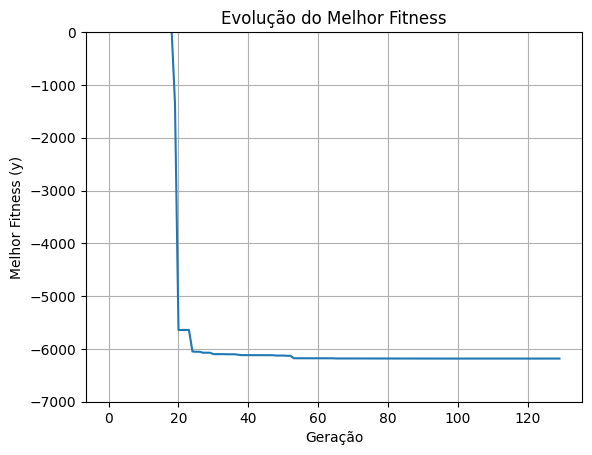

In [ ]:
import matplotlib.pyplot as plt

def main():

  pop_inicial = gerar_populacao_inicial()
  pop_bin = converter_populacao_para_binario(pop_inicial)
  print(pop_inicial)
  melhores_fitness = []
  for geracao in range(130):
    pop_bin = calcular_fitness(pop_bin) #calculo ftness
    elite = elitismo(pop_bin) #elitismo
    filhos = gerar_filhos(pop_bin) #filhos
    filhos_mutados = mutacao(filhos) #mutacao
    filhos_avaliados = calcular_fitness(filhos_mutados) #calculo fitness (novo)
    pop_bin = filhos_avaliados + elite #elite + filhos
    pop_real = pop_para_real(pop_bin) #bin -> real

    # melhor de cada geração
    melhor = min(pop_real, key=lambda ind: ind[2])
    melhores_fitness.append(melhor[2])

    print(f"Geração {geracao}: melhor y = {melhor[2]}, x1: {melhor[0]}, x2: {melhor[1]}")

  # GRÁFICO
  plt.plot(melhores_fitness)
  plt.ylim(MIN_PLOT, MAX_PLOT)
  plt.xlabel("Geração")
  plt.ylabel("Melhor Fitness (y)")
  plt.title("Evolução do Melhor Fitness")
  plt.grid()
  plt.show()

main()